Data loaded: 1529 days
Error loading ../models/dqn_final_tuned.pth: Error(s) in loading state_dict for DQN:
	size mismatch for net.0.weight: copying a param with shape torch.Size([128, 7]) from checkpoint, the shape in current model is torch.Size([128, 6]).

--- COVID Crash (2020) ---
Return       : -17.77%
Max Drawdown : -17.77%
Long         : 5.3% | Short : 26.3% | Flat : 68.4%

--- Recovery 2020 ---
Return       : -19.23%
Max Drawdown : -22.52%
Long         : 0.0% | Short : 20.8% | Flat : 79.2%

--- Bull 2021 ---
Return       : -18.94%
Max Drawdown : -20.39%
Long         : 0.4% | Short : 26.3% | Flat : 73.3%

--- High Vol 2022 ---
Return       : 1.15%
Max Drawdown : -9.03%
Long         : 2.0% | Short : 28.4% | Flat : 69.6%

=== REGIME SUMMARY TABLE ===
               Regime  Return (%)  MaxDD (%)  Long %  Short %  Flat %
0  COVID Crash (2020)      -17.77     -17.77     5.3     26.3    68.4
1       Recovery 2020      -19.23     -22.52     0.0     20.8    79.2
2           Bull 2021   

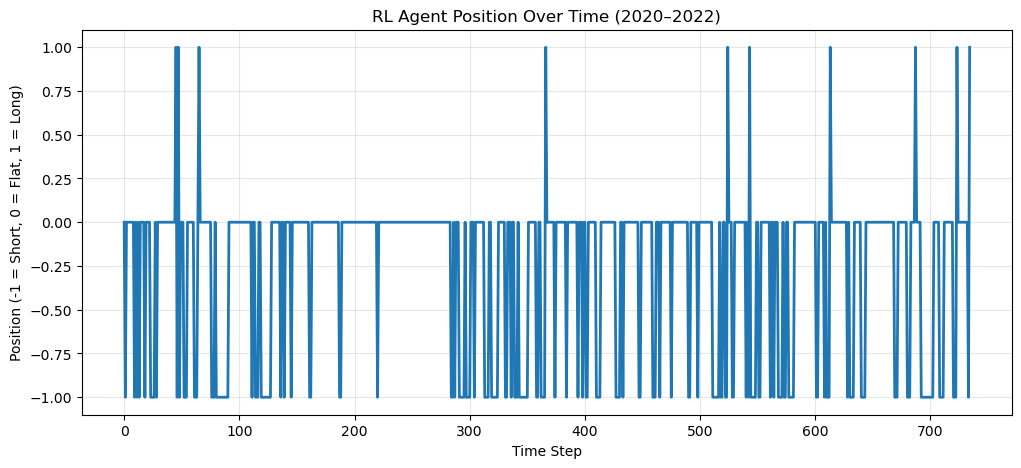

In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================
# 1. LOAD DATA
# =============================================
state_data = pd.read_csv("../data/state_dataset.csv", index_col="Date", parse_dates=True)
market_data = pd.read_csv("../data/market_master.csv", index_col="Date", parse_dates=True)
data = state_data.join(market_data[["nifty_ret"]], how="inner")

print(f"Data loaded: {data.shape[0]} days")

# =============================================
# 2. ENVIRONMENT (Consistent with Day 35)
# =============================================
class QuantumAlphaEnv:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.max_steps = len(self.data) - 1
        self.feature_cols = [
            "mom_20_norm", "vol_signal_norm", "trend_signal_norm",
            "dd_signal_norm", "vix_signal_norm", "breadth_signal_norm"
        ]
        self.reset()
    
    def reset(self):
        self.current_step = 0
        self.position = 0
        self.balance = 1.0
        self.peak_balance = 1.0
        return self._get_observation()
    
    def _get_observation(self):
        row = self.data.iloc[self.current_step]
        return row[self.feature_cols].values.astype(np.float32)
    
    def step(self, action):
        new_position = {0: 0, 1: 1, 2: -1}[action]
        prev_position = self.position
        current_ret = self.data.iloc[self.current_step]["nifty_ret"]
        
        cost = abs(new_position - prev_position) * 0.0005
        net_ret = prev_position * current_ret - cost   # return based on PREVIOUS position
        
        self.balance *= (1 + net_ret)
        self.peak_balance = max(self.peak_balance, self.balance)
        self.position = new_position
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self._get_observation(), net_ret, done, {
            "net_ret": net_ret,
            "position": self.position
        }

# =============================================
# 3. DQN MODEL
# =============================================
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_size)
        )
    def forward(self, x):
        return self.net(x)

# Load the model - try multiple possible names
model_paths = [
    "../models/dqn_best_policy.pth",
    "../models/dqn_policy_final.pth",
    "../models/dqn_policy_final_2019_2022.pth",
    "../models/dqn_final_tuned.pth"
]

policy_net = None
for path in model_paths:
    try:
        policy_net = DQN(6, 3).to(device)
        policy_net.load_state_dict(torch.load(path, map_location=device))
        print(f"  Model loaded successfully from: {path}")
        break
    except FileNotFoundError:
        continue
    except Exception as e:
        print(f"Error loading {path}: {e}")

if policy_net is None:
    print("  No model file found. Using random weights for demonstration.")
    policy_net = DQN(6, 3).to(device)

policy_net.eval()

# =============================================
# 4. REGIME ANALYSIS FUNCTION
# =============================================
def analyze_regime(start_date, end_date, name):
    period = data.loc[start_date:end_date].copy()
    if len(period) == 0:
        print(f"Warning: No data for {name}")
        return None
    
    env = QuantumAlphaEnv(period)
    
    state = env.reset()
    done = False
    positions = []
    equity = 1.0
    equity_curve = [1.0]
    
    while not done:
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(device)
            action = policy_net(s).argmax().item()
        
        next_state, reward, done, info = env.step(action)
        
        equity *= (1 + info["net_ret"])
        equity_curve.append(equity)
        positions.append(info["position"])
        
        state = next_state
    
    positions = np.array(positions)
    long_pct = (positions == 1).mean()
    short_pct = (positions == -1).mean()
    flat_pct = (positions == 0).mean()
    
    total_return = equity - 1
    max_dd = (np.array(equity_curve) / np.maximum.accumulate(equity_curve) - 1).min()
    
    print(f"\n--- {name} ---")
    print(f"Return       : {total_return:.2%}")
    print(f"Max Drawdown : {max_dd:.2%}")
    print(f"Long         : {long_pct:.1%} | Short : {short_pct:.1%} | Flat : {flat_pct:.1%}")
    
    return {
        "Regime": name,
        "Return (%)": round(total_return*100, 2),
        "MaxDD (%)": round(max_dd*100, 2),
        "Long %": round(long_pct*100, 1),
        "Short %": round(short_pct*100, 1),
        "Flat %": round(flat_pct*100, 1)
    }

# =============================================
# 5. DEFINE REGIMES
# =============================================
regimes = {
    "COVID Crash (2020)": ("2020-02-01", "2020-04-30"),
    "Recovery 2020": ("2020-05-01", "2020-12-31"),
    "Bull 2021": ("2021-01-01", "2021-12-31"),
    "High Vol 2022": ("2022-01-01", "2022-10-31")
}

results = []
for name, (start, end) in regimes.items():
    result = analyze_regime(start, end, name)
    if result:
        results.append(result)

summary_df = pd.DataFrame(results)
print("\n=== REGIME SUMMARY TABLE ===")
print(summary_df)

# =============================================
# 6. POSITION VISUALIZATION (2020-2022)
# =============================================
env = QuantumAlphaEnv(data.loc["2020":"2022"])
state = env.reset()
done = False
positions_over_time = []

while not done:
    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        action = policy_net(s).argmax().item()
    _, _, done, _ = env.step(action)
    positions_over_time.append(env.position)
    state = env._get_observation()

plt.figure(figsize=(12, 5))
plt.plot(positions_over_time, linewidth=2)
plt.title("RL Agent Position Over Time (2020–2022)")
plt.xlabel("Time Step")
plt.ylabel("Position (-1 = Short, 0 = Flat, 1 = Long)")
plt.grid(True, alpha=0.3)
plt.show()
